# Final Project - Tsunami Events Analysis

**Maëlis Nohe Estrada, Raoul Dragus, Reda Ait Taleb**  
**Problématique :** *Understanding Temporal, Spatial and Physical Characteristics of Tsunami Events*  
**Question principale :** *Quels facteurs temporels, spatiaux et physiques permettent de mieux comprendre la distribution et l'impact des tsunamis ?*

## 1. Introduction

Le projet final vise à analyser des événements de tsunamis afin de comprendre leur distribution dans le temps, leur répartition géographique et certaines caractéristiques physiques ou humaines associées à leur impact.

Pour structurer cette analyse, le notebook suit le **KDD process** (*Knowledge Discovery in Databases*). Cette démarche permet d'organiser le travail depuis la compréhension du sujet et l'exploration des données jusqu'à la construction d'indicateurs interprétables et utiles.

Les tsunamis peuvent être analysés avec des données car chaque événement laisse des informations observables : date, localisation, magnitude du séisme associé, intensité du tsunami, profondeur, cause ou encore descriptions de dommages. L'objectif du projet est donc d'extraire des informations utiles à partir d'événements temporels, spatiaux et analytiques.

## 2. About the dataset

Le dataset retenu pour ce projet est **tsunami_dataset.csv**. Chaque ligne représente un événement tsunami, ou un événement historique relié à un tsunami, documenté à travers plusieurs variables de contexte.

Le dataset permet de décrire :
- quand l'événement s'est produit ;
- où il s'est produit ;
- quelles caractéristiques physiques et quels impacts lui sont associés.

Trois dimensions sont directement présentes dans le jeu de données :
- **dimension temporelle** : YEAR, MONTH, DAY, HOUR, MINUTE ;
- **dimension spatiale** : LATITUDE, LONGITUDE, COUNTRY, REGION, LOCATION_NAME ;
- **dimension analytique** : CAUSE, EVENT_VALIDITY, EQ_MAGNITUDE, EQ_DEPTH, TS_INTENSITY, ainsi que les descriptions d'impact DAMAGE_TOTAL_DESCRIPTION, HOUSES_TOTAL_DESCRIPTION et DEATHS_TOTAL_DESCRIPTION.

Cette structure rend le dataset adapté à une analyse multidimensionnelle des tsunamis.

## 3. Imports

In [1]:
import warnings
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import HTML, display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")

## 4. Data loading functions

In [2]:
def find_csv_files(folder_path: Path) -> List[Path]:
    """
    Input:
        folder_path: path to the project folder.
    Output:
        list of CSV files found in the folder.
    """
    # Recherche des fichiers CSV directement dans le dossier du projet.
    return sorted(folder_path.glob('*.csv'))


def load_data(csv_path: Path) -> pd.DataFrame:
    """
    Input:
        csv_path: path to the tsunami CSV file.
    Output:
        pandas DataFrame containing the raw dataset.
    """
    # Chargement du CSV principal avec une inference de type stable.
    return pd.read_csv(csv_path, low_memory=False)


def select_tsunami_csv(csv_files: List[Path]) -> Path:
    """
    Input:
        csv_files: list of CSV files.
    Output:
        selected path corresponding to tsunami_dataset.csv.
    """
    # Priorite au fichier explicitement nomme tsunami_dataset.csv.
    for csv_path in csv_files:
        if csv_path.name.lower() == 'tsunami_dataset.csv':
            print(f"Selected tsunami CSV: {csv_path.name}")
            return csv_path

    # Sinon, le premier CSV disponible est retenu avec un message explicite.
    selected_path = csv_files[0]
    print(f"tsunami_dataset.csv was not found. Using {selected_path.name} instead.")
    return selected_path

In [3]:
project_dir = Path.cwd()
csv_files = find_csv_files(project_dir)
print('CSV files found:', [path.name for path in csv_files])

selected_csv_path = select_tsunami_csv(csv_files)
df = load_data(selected_csv_path)
print('Main CSV selected:', selected_csv_path.name)
display(df.head())

CSV files found: ['tsunami_dataset.csv']
Selected tsunami CSV: tsunami_dataset.csv
Main CSV selected: tsunami_dataset.csv


,ID,YEAR,MONTH,DAY,HOUR,MINUTE,LATITUDE,LONGITUDE,LOCATION_NAME,COUNTRY,REGION,CAUSE,EVENT_VALIDITY,EQ_MAGNITUDE,EQ_DEPTH,TS_INTENSITY,DAMAGE_TOTAL_DESCRIPTION,HOUSES_TOTAL_DESCRIPTION,DEATHS_TOTAL_DESCRIPTION,URL,COMMENTS
0,12,-330,NaN,NaN,NaN,NaN,40.000,25.000,"E. SPORADES ISLANDS, AEGEAN ISLANDS",GREECE,Mediterranean Sea,Earthquake,Very Doubtful Tsunami,7.000,NaN,NaN,NaN,NaN,NaN,https://www.ngdc.noaa.gov/hazel/view/hazards/t...,"330 B.C. Aegean Sea, Sporades Islands, 40 N 25..."
1,481,1764,2.000,11.000,NaN,NaN,51.450,-2.583,"BRISTOL, ENGLAND",UK,Northeast Atlantic Ocean,Unknown,Very Doubtful Tsunami,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ngdc.noaa.gov/hazel/view/hazards/t...,"Reference #1894, in full: ""On Saturday the 11t..."
2,71,859,NaN,NaN,NaN,NaN,36.080,36.250,SAMANDAGI,TURKEY,Mediterranean Sea,Earthquake,Questionable Tsunami,NaN,NaN,3.000,NaN,NaN,NaN,https://www.ngdc.noaa.gov/hazel/view/hazards/t...,"859 (possibly 861), November. Levantian Sea, N..."
3,186,1580,1.000,NaN,NaN,NaN,40.000,128.000,YELLOW SEA,NORTH KOREA,"China, North and South Korea, Philippines, Taiwan",Unknown,Very Doubtful Tsunami,NaN,NaN,1.000,NaN,NaN,NaN,https://www.ngdc.noaa.gov/hazel/view/hazards/t...,<P><blockquote><i>Reference #414:</i></blockqu...
4,5,-1300,NaN,NaN,NaN,NaN,39.960,26.240,"IONIAN COASTS, TROAD",TURKEY,Mediterranean Sea,Unknown,Questionable Tsunami,6.000,NaN,5.000,NaN,NaN,NaN,https://www.ngdc.noaa.gov/hazel/view/hazards/t...,1300 B.C. Ionian and Aegean Seas. References t...


## 5. Data exploration

In [4]:
def explore_dataset(df: pd.DataFrame) -> Dict[str, object]:
    """
    Input:
        df: raw tsunami DataFrame.
    Output:
        dictionary containing shape, columns, dtypes and descriptive statistics.
    """
    # Regroupement des principaux elements descriptifs dans une structure unique.
    return {
        'shape': df.shape,
        'columns': df.columns.tolist(),
        'dtypes': df.dtypes.to_frame(name='dtype'),
        'describe': df.describe(include='all').transpose(),
    }


def missing_values_report(df: pd.DataFrame) -> pd.DataFrame:
    """
    Input:
        df: tsunami DataFrame.
    Output:
        DataFrame with missing values count and percentage by column.
    """
    # Comptage des valeurs manquantes et calcul du pourcentage par colonne.
    report = pd.DataFrame({
        'missing_count': df.isna().sum(),
        'missing_percentage': (df.isna().sum() / len(df)) * 100,
    }).sort_values('missing_count', ascending=False)
    return report


def numeric_range_report(df: pd.DataFrame) -> pd.DataFrame:
    """
    Input:
        df: tsunami DataFrame.
    Output:
        DataFrame with min and max values for numeric columns.
    """
    numeric_df = df.select_dtypes(include='number')
    # Presentation des bornes minimales et maximales pour chaque variable numerique.
    return pd.DataFrame({
        'min': numeric_df.min(),
        'max': numeric_df.max(),
    }).sort_index()

In [5]:
exploration = explore_dataset(df)
missing_report = missing_values_report(df)
range_report = numeric_range_report(df)

print('Shape:', exploration['shape'])
print('\nColumns:')
display(pd.DataFrame({'column_name': exploration['columns']}))
print('\nData types:')
display(exploration['dtypes'])
print('\nMissing values report:')
display(missing_report)
print('\nDescriptive statistics:')
display(exploration['describe'])
print('\nNumeric ranges:')
display(range_report)

Shape: (2259, 21)

Columns:


,column_name
0,ID
1,YEAR
2,MONTH
3,DAY
4,HOUR
5,MINUTE
6,LATITUDE
7,LONGITUDE
8,LOCATION_NAME
9,COUNTRY



Data types:


,dtype
ID,int64
YEAR,int64
MONTH,float64
DAY,float64
HOUR,float64
MINUTE,float64
LATITUDE,float64
LONGITUDE,float64
LOCATION_NAME,object
COUNTRY,object



Missing values report:


,missing_count,missing_percentage
HOUSES_TOTAL_DESCRIPTION,1653,73.174
DEATHS_TOTAL_DESCRIPTION,1585,70.164
EQ_DEPTH,1352,59.849
DAMAGE_TOTAL_DESCRIPTION,1204,53.298
TS_INTENSITY,1158,51.262
MINUTE,1024,45.330
HOUR,951,42.098
EQ_MAGNITUDE,785,34.750
DAY,177,7.835
COMMENTS,164,7.260



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,"2,259.000",NaN,NaN,NaN,"2,332.022","1,665.174",1.000,"1,090.500","1,932.000","3,353.000","5,753.000"
YEAR,"2,259.000",NaN,NaN,NaN,"1,819.188",354.082,"-2,000.000","1,835.500","1,909.000","1,968.000","2,020.000"
MONTH,"2,155.000",NaN,NaN,NaN,6.623,3.460,1.000,4.000,7.000,10.000,12.000
DAY,"2,082.000",NaN,NaN,NaN,15.701,8.657,1.000,8.000,16.000,23.000,31.000
HOUR,"1,308.000",NaN,NaN,NaN,11.319,6.980,0.000,5.000,11.000,18.000,23.000
MINUTE,"1,235.000",NaN,NaN,NaN,28.354,17.223,0.000,14.000,29.000,43.000,59.000
LATITUDE,"2,259.000",NaN,NaN,NaN,17.002,27.731,-63.000,-5.000,23.000,38.670,71.813
LONGITUDE,"2,259.000",NaN,NaN,NaN,40.346,104.605,-179.971,-70.200,34.400,137.833,179.984
LOCATION_NAME,2250,861,NORTHERN CHILE,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTRY,2259,103,JAPAN,308,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Numeric ranges:


,min,max
DAY,1.000,31.000
EQ_DEPTH,0.000,600.000
EQ_MAGNITUDE,3.200,9.500
HOUR,0.000,23.000
ID,1.000,"5,753.000"
LATITUDE,-63.000,71.813
LONGITUDE,-179.971,179.984
MINUTE,0.000,59.000
MONTH,1.000,12.000
TS_INTENSITY,-4.140,9.000


### Observations

Le dataset contient **2259 lignes** et **21 colonnes**. Les colonnes temporelles visibles dans les resultats sont : **YEAR, MONTH, DAY, HOUR, MINUTE**. Les colonnes spatiales identifiables sont : **LATITUDE, LONGITUDE, COUNTRY, REGION, LOCATION_NAME**. Les principales colonnes analytiques exploitables sont : **CAUSE, EVENT_VALIDITY, EQ_MAGNITUDE, EQ_DEPTH, TS_INTENSITY, DAMAGE_TOTAL_DESCRIPTION, HOUSES_TOTAL_DESCRIPTION, DEATHS_TOTAL_DESCRIPTION**.

Le rapport de valeurs manquantes montre que certaines variables d'impact descriptif ou physique sont incompletes. Les colonnes les plus touchees sont notamment **HOUSES_TOTAL_DESCRIPTION**, **DEATHS_TOTAL_DESCRIPTION**, **EQ_DEPTH** et **DAMAGE_TOTAL_DESCRIPTION**.

### Interprétation

Le jeu de données est bien multidimensionnel. Il combine des informations sur le moment des événements, leur localisation et plusieurs caractéristiques physiques ou descriptives, ce qui le rend adapté à une analyse du sujet proposé.

### Limits

- Certaines variables sont incomplètes et ne pourront pas être utilisées de la même manière dans tous les indicateurs.
- Les événements historiques anciens peuvent être documentés de façon moins précise.
- Les impacts déclarés peuvent dépendre de la qualité et de l'homogénéité des sources historiques.

### Mini-conclusion

Le dataset est exploitable pour construire des indicateurs temporels, spatiaux et analytiques. La richesse des variables disponibles permet d'etudier les tsunamis selon plusieurs angles complementaires.

## 6. Preprocessing

In [6]:
def preprocess_tsunami_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Input:
        df: raw tsunami DataFrame.
    Output:
        cleaned DataFrame with numeric columns converted and useful date fields prepared.
    """
    cleaned_df = df.copy()

    numeric_columns = [
        'YEAR', 'MONTH', 'DAY', 'HOUR', 'MINUTE', 'LATITUDE', 'LONGITUDE',
        'EQ_MAGNITUDE', 'EQ_DEPTH', 'TS_INTENSITY', 'DAMAGE', 'HOUSES', 'DEATHS'
    ]

    # Conversion numerique uniquement pour les colonnes presentes dans le dataset.
    for column in numeric_columns:
        if column in cleaned_df.columns:
            cleaned_df[column] = pd.to_numeric(cleaned_df[column], errors='coerce')

    # Creation d'une date complete quand YEAR, MONTH et DAY sont exploitables.
    if all(col in cleaned_df.columns for col in ['YEAR', 'MONTH', 'DAY']):
        cleaned_df['EVENT_DATE'] = pd.to_datetime(
            {
                'year': cleaned_df['YEAR'],
                'month': cleaned_df['MONTH'],
                'day': cleaned_df['DAY'],
            },
            errors='coerce'
        )
    else:
        cleaned_df['EVENT_DATE'] = pd.NaT

    # Regroupement par decennie pour faciliter certaines lectures temporelles.
    if 'YEAR' in cleaned_df.columns:
        cleaned_df['DECADE'] = (cleaned_df['YEAR'] // 10) * 10
    else:
        cleaned_df['DECADE'] = np.nan

    return cleaned_df

In [7]:
cleaned_df = preprocess_tsunami_data(df)
display(cleaned_df[['YEAR', 'MONTH', 'DAY', 'EVENT_DATE', 'DECADE']].head(10))

,YEAR,MONTH,DAY,EVENT_DATE,DECADE
0,-330,NaN,NaN,NaT,-330
1,1764,2.000,11.000,1764-02-11,1760
2,859,NaN,NaN,NaT,850
3,1580,1.000,NaN,NaT,1580
4,-1300,NaN,NaN,NaT,-1300
5,-47,9.000,NaN,NaT,-50
6,1556,10.000,21.000,NaT,1550
7,1641,12.000,21.000,NaT,1640
8,1747,3.000,NaN,NaT,1740
9,1606,1.000,23.000,NaT,1600


Le nettoyage est volontairement **local** et non global. Cette approche permet d'éviter la suppression prématurée d'un grand nombre de lignes, alors que chaque indicateur ne mobilise pas les mêmes variables. Les valeurs manquantes sont donc filtrées uniquement au moment où elles deviennent nécessaires pour un calcul précis.

## Information building

### Indicator 1 - Grouping query: Countries with the highest number of tsunami events

#### How it is calculated

Cet indicateur est calculé en supprimant uniquement les lignes pour lesquelles **COUNTRY** est manquant, puis en appliquant un **groupby COUNTRY** suivi d'un **count**. Les pays sont ensuite triés par nombre d'événements en ordre décroissant, et les 15 premiers sont conservés.

#### What it represents

Il représente le nombre d'événements de tsunamis enregistrés par pays dans le dataset.

In [8]:
def compute_top_countries_by_events(df: pd.DataFrame, top_n: int = 15) -> pd.DataFrame:
    """
    Input:
        df: cleaned tsunami DataFrame.
        top_n: number of countries to display.
    Output:
        DataFrame containing countries and number of tsunami events.
    """
    if 'COUNTRY' not in df.columns:
        raise KeyError('COUNTRY column is required for this indicator.')

    # Suppression locale des pays manquants avant l'agregation.
    data = df[['COUNTRY']].dropna(subset=['COUNTRY']).copy()

    # Comptage du nombre d'evenements par pays.
    result = (
        data.groupby('COUNTRY', as_index=False)
        .size()
        .rename(columns={'size': 'event_count'})
        .sort_values('event_count', ascending=False)
        .head(top_n)
    )
    return result

,COUNTRY,event_count
46,JAPAN,308
41,INDONESIA,223
97,USA,164
9,CHILE,153
31,GREECE,141
44,ITALY,110
74,RUSSIA,90
72,PHILIPPINES,87
70,PAPUA NEW GUINEA,74
62,NEW ZEALAND,73


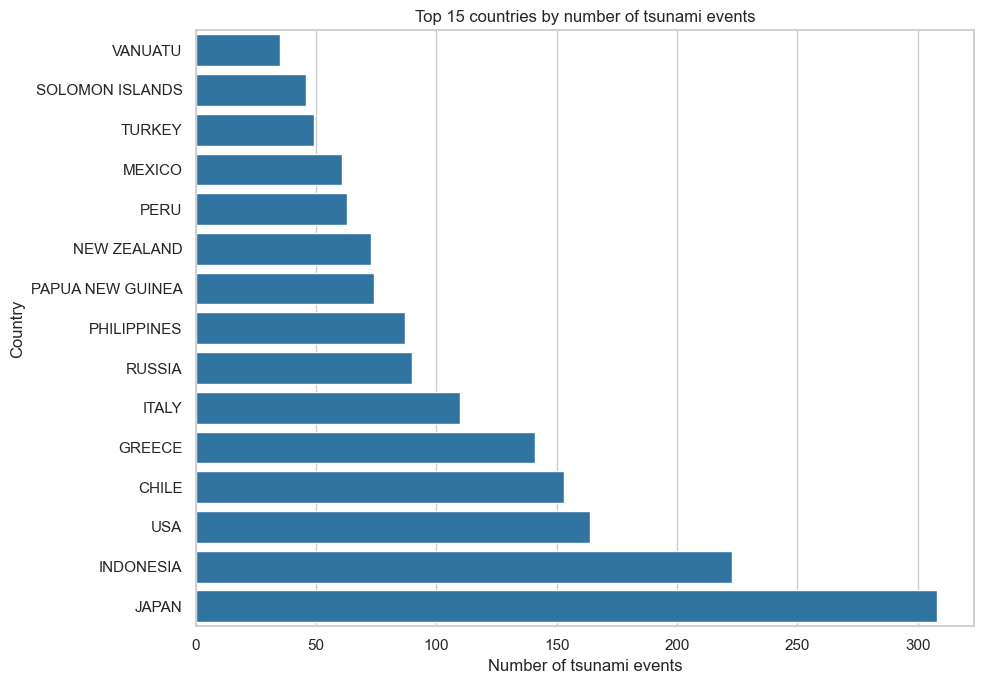

In [9]:
top_countries = compute_top_countries_by_events(cleaned_df, top_n=15)
display(top_countries)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_countries.sort_values('event_count', ascending=True), x='event_count', y='COUNTRY', color='#1f77b4')
plt.title('Top 15 countries by number of tsunami events')
plt.xlabel('Number of tsunami events')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Observations

Le tableau et le graphique montrent que les pays les plus représentés dans le top du dataset sont notamment **JAPAN (308), INDONESIA (223), USA (164), CHILE (153), GREECE (141)**. L'écart entre les premiers pays et ceux qui apparaissent plus bas dans le classement reste visible, ce qui suggère une concentration non uniforme des événements enregistrés.

### Interprétation

Cet indicateur met en évidence les pays les plus présents dans le dataset. Il renseigne sur la **représentation historique et géographique** des événements enregistrés, mais il ne permet pas à lui seul de conclure que ces pays sont nécessairement les plus dangereux sans tenir compte de la couverture documentaire et de l'intensité des événements.

### Limits

- Le résultat dépend de la qualité de l'enregistrement historique selon les pays.
- Un pays présentant beaucoup d'événements n'est pas nécessairement celui qui a connu les impacts les plus destructeurs.
- Le classement ne tient pas compte des différences d'intensité ou de dommages entre les événements.

### Mini-conclusion

Cet indicateur apporte une première lecture territoriale du dataset. Il permet d'identifier les pays les plus fréquemment associés aux événements de tsunami enregistrés et constitue une base utile pour les analyses spatiales ultérieures.

### Indicator 2 - Advanced technique: Tsunami event clustering

#### How it is calculated

Le clustering repose sur la sélection des variables **LATITUDE**, **LONGITUDE**, **EQ_MAGNITUDE**, **EQ_DEPTH** et **TS_INTENSITY** lorsque celles-ci sont disponibles. Les lignes incomplètes sur ces variables sont filtrées localement, puis les variables sont **standardisées** avec `StandardScaler`. Le modèle **KMeans** est ensuite appliqué avec `n_clusters=4`, `random_state=42` et `n_init=10`.

#### What it represents

Il représente des groupes d'événements partageant des caractéristiques physiques et spatiales similaires.

In [10]:
def cluster_tsunami_events(df: pd.DataFrame, n_clusters: int = 4) -> Dict[str, object]:
    """
    Input:
        df: cleaned tsunami DataFrame.
        n_clusters: number of clusters.
    Output:
        dictionary containing clustered DataFrame, cluster summary and features used.
    """
    feature_columns = ['LATITUDE', 'LONGITUDE', 'EQ_MAGNITUDE', 'EQ_DEPTH', 'TS_INTENSITY']
    missing_columns = [col for col in feature_columns if col not in df.columns]
    if missing_columns:
        raise KeyError(f'Missing required columns: {missing_columns}')

    # Preparation locale des variables utiles au clustering.
    cluster_data = df[feature_columns + [c for c in ['COUNTRY', 'REGION', 'LOCATION_NAME'] if c in df.columns]].copy()
    for column in feature_columns:
        cluster_data[column] = pd.to_numeric(cluster_data[column], errors='coerce')

    # Conservation des lignes completes pour les seules variables du modele.
    cluster_data = cluster_data.dropna(subset=feature_columns).copy()

    # Normalisation des variables pour equilibrer leur contribution dans KMeans.
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(cluster_data[feature_columns])

    # Construction des clusters de tsunamis.
    model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_data['tsunami_cluster'] = model.fit_predict(scaled_features)

    cluster_summary = cluster_data.groupby('tsunami_cluster')[feature_columns].mean().round(3)

    return {
        'clustered_df': cluster_data,
        'cluster_summary': cluster_summary,
        'features_used': feature_columns,
    }

,LATITUDE,LONGITUDE,EQ_MAGNITUDE,EQ_DEPTH,TS_INTENSITY
tsunami_cluster,,,,,
0,14.775,123.048,7.558,41.229,1.681
1,0.170,-104.356,7.627,39.571,0.938
2,32.736,108.385,6.628,32.900,-0.818
3,-2.000,119.500,7.900,550.000,2.000


,number_of_events
tsunami_cluster,
0,144
1,91
2,150
3,2


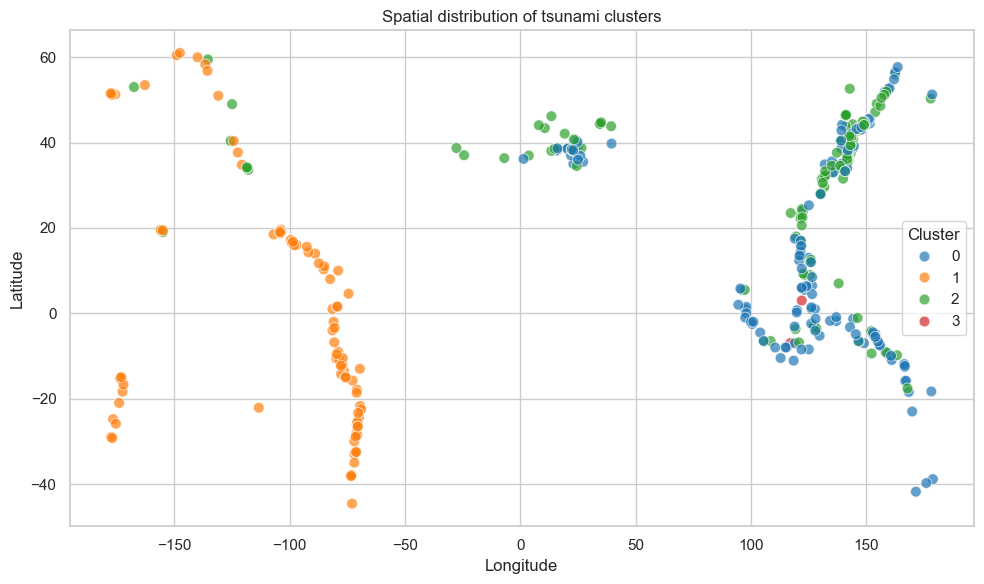

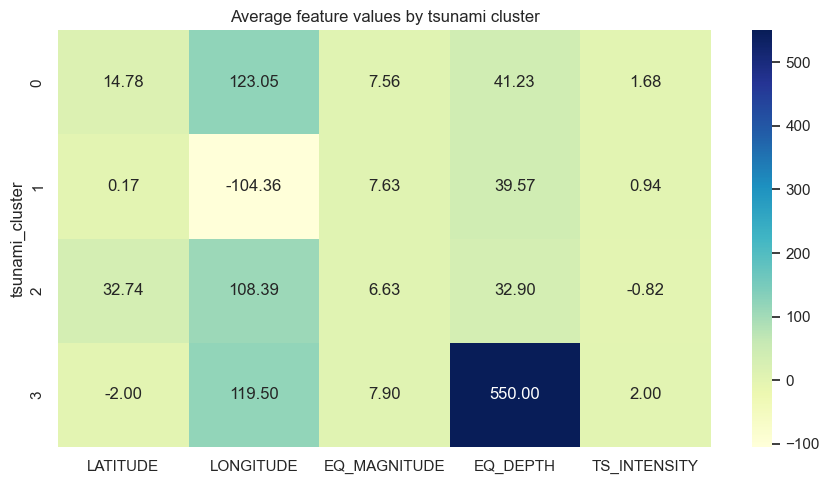

In [11]:
cluster_results = cluster_tsunami_events(cleaned_df, n_clusters=4)
clustered_events = cluster_results['clustered_df']
cluster_summary = cluster_results['cluster_summary']
cluster_sizes = clustered_events['tsunami_cluster'].value_counts().sort_index().to_frame(name='number_of_events')

display(cluster_summary)
display(cluster_sizes)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clustered_events,
    x='LONGITUDE',
    y='LATITUDE',
    hue='tsunami_cluster',
    palette='tab10',
    alpha=0.7,
    s=60,
)
plt.title('Spatial distribution of tsunami clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.heatmap(cluster_summary, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Average feature values by tsunami cluster')
plt.tight_layout()
plt.show()

### Observations

Le tableau des moyennes montre des profils différenciés entre les clusters. Le **cluster 3** présente la moyenne de **EQ_MAGNITUDE** la plus élevée, tandis qu'il se distingue aussi par la profondeur moyenne (**EQ_DEPTH**) et l'intensité moyenne (**TS_INTENSITY**) les plus élevées parmi les groupes observés.

Le tableau des effectifs montre cependant que le **cluster 3** ne contient que **2 événements**. Il doit donc être interprété comme un **groupe atypique** plutôt que comme un profil général des tsunamis du dataset. Le nuage de points longitude / latitude fait par ailleurs apparaêtre une séparation partielle des groupes dans l'espace géographique.

### Interprétation

Le clustering permet d'identifier des **profils d'événements** partageant des caractéristiques proches. Ces groupes ne constituent pas des catégories naturelles officielles des tsunamis, mais une organisation statistique des observations disponible dans ce dataset. Ils sont utiles pour mettre en perspective des combinaisons de localisation, magnitude, profondeur et intensité.

### Limits

- Le résultat dépend du nombre de clusters choisi.
- Il dépend également des variables retenues pour construire le modèle.
- KMeans suppose des groupes relativement compacts, ce qui peut être réducteur pour des phénomènes géophysiques complexes.
- Les valeurs manquantes réduisent l'échantillon effectivement utilisé pour le clustering.

### Mini-conclusion

Le clustering apporte une lecture structurelle complémentaire du dataset. Il montre que les événements peuvent être regroupés selon plusieurs profils physiques et spatiaux, ce qui enrichit l'analyse au-delà d'un simple comptage descriptif.

### Indicator 3 - Temporal query: Evolution of tsunami events over time

#### How it is calculated

L'indicateur est calculé en supprimant uniquement les lignes pour lesquelles **YEAR** est manquant, puis en appliquant un **groupby YEAR** suivi d'un **count**. Les années sont triées dans l'ordre chronologique, puis une moyenne glissante sur **10 ans** est calculée lorsque le nombre de lignes le permet.

#### What it represents

Il représente l'évolution temporelle du nombre d'événements enregistrés dans le dataset.

In [12]:
def compute_events_over_time(df: pd.DataFrame) -> pd.DataFrame:
    """
    Input:
        df: cleaned tsunami DataFrame.
    Output:
        DataFrame containing number of tsunami events by year and rolling average.
    """
    if 'YEAR' not in df.columns:
        raise KeyError('YEAR column is required for this indicator.')

    # Filtrage local des annees manquantes avant l'agregation temporelle.
    temporal_data = df[['YEAR']].dropna(subset=['YEAR']).copy()

    # Comptage du nombre d'evenements par annee.
    result = (
        temporal_data.groupby('YEAR', as_index=False)
        .size()
        .rename(columns={'size': 'event_count'})
        .sort_values('YEAR')
    )

    # Calcul d'une moyenne glissante sur 10 ans quand suffisamment de points sont disponibles.
    if len(result) >= 10:
        result['rolling_average_10y'] = result['event_count'].rolling(window=10, min_periods=3).mean()
    else:
        result['rolling_average_10y'] = np.nan

    return result

,YEAR,event_count,rolling_average_10y
0,-2000,1,NaN
1,-1610,1,NaN
2,-1365,1,1.000
3,-1300,1,1.000
4,-590,1,1.000
5,-525,1,1.000
6,-480,1,1.000
7,-479,1,1.000
8,-426,1,1.000
9,-373,1,1.000


,YEAR,event_count,rolling_average_10y
420,1928,22,11.400
430,1938,19,10.900
370,1878,19,8.700
486,1994,19,9.200
509,2017,18,14.900
487,1995,17,10.300
502,2010,17,11.100
499,2007,17,8.800
503,2011,17,12.400
460,1968,16,11.500


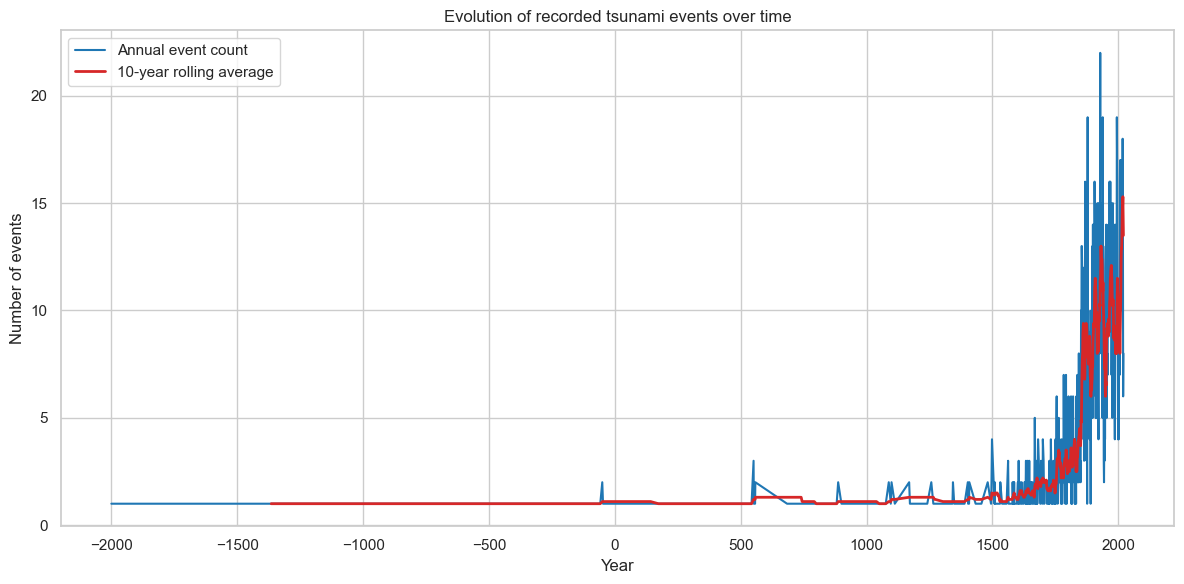

In [13]:
events_by_year = compute_events_over_time(cleaned_df)
display(events_by_year.head(15))

display(events_by_year.sort_values('event_count', ascending=False).head(10))

plt.figure(figsize=(12, 6))
plt.plot(events_by_year['YEAR'], events_by_year['event_count'], color='#1f77b4', linewidth=1.5, label='Annual event count')
if events_by_year['rolling_average_10y'].notna().sum() > 0:
    plt.plot(events_by_year['YEAR'], events_by_year['rolling_average_10y'], color='#d62728', linewidth=2.0, label='10-year rolling average')
plt.title('Evolution of recorded tsunami events over time')
plt.xlabel('Year')
plt.ylabel('Number of events')
plt.legend()
plt.tight_layout()
plt.show()

### Observations

Le graphique montre des variations importantes du nombre d'événements enregistrés selon les années. Parmi les années les plus fréquentes dans le dataset figurent notamment **1928 (22), 1938 (19), 1878 (19), 1994 (19), 2017 (18)**. La moyenne glissante sur 10 ans lisse cette variabilité et met en évidence des fluctuations de fond plutôt qu'un profil uniforme.

La série couvre une longue période historique, de **-2000** à **2020**, ce qui confirme la profondeur temporelle du dataset.

### Interprétation

Cet indicateur aide à lire l'évolution temporelle des événements documentés. Les variations observées peuvent refléter à la fois l'activité réelle, l'amélioration de l'observation scientifique et la qualité variable de l'enregistrement historique. Il convient donc d'éviter toute conclusion causale trop directe sur une hausse ou une baisse structurelle.

### Limits

- Les événements anciens sont potentiellement moins bien documentés.
- Les dispositifs modernes de détection et d'archivage sont plus performants que ceux des périodes anciennes.
- Cet indicateur décrit une série historique et ne constitue pas une prévision causale.

### Mini-conclusion

L'indicateur temporel apporte une lecture historique du dataset et montre que la distribution des événements varie selon les périodes observées. Il constitue une dimension essentielle pour comprendre la structure du corpus documentaire.

### Indicator 4 - Spatial query: Geographic distribution of tsunami events

#### How it is calculated

L'indicateur est obtenu en vérifiant la présence des colonnes **LATITUDE** et **LONGITUDE**, puis en convertissant ces variables en numérique si nécessaire. Les lignes sans coordonnées valides sont exclues localement, et les variables informatives disponibles telles que **COUNTRY**, **REGION**, **LOCATION_NAME**, **YEAR** ou **TS_INTENSITY** sont conservées pour l'affichage cartographique.

#### What it represents

Il représente la localisation géographique des événements de tsunami enregistrés dans le dataset.

In [14]:
def compute_spatial_distribution(df: pd.DataFrame) -> pd.DataFrame:
    """
    Input:
        df: cleaned tsunami DataFrame.
    Output:
        DataFrame containing valid latitude, longitude and event information.
    """
    required_columns = ['LATITUDE', 'LONGITUDE']
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise KeyError(f'Missing required columns: {missing_columns}')

    keep_columns = [column for column in ['LATITUDE', 'LONGITUDE', 'COUNTRY', 'REGION', 'LOCATION_NAME', 'YEAR', 'TS_INTENSITY'] if column in df.columns]
    spatial_data = df[keep_columns].copy()

    # Conversion numerique locale des coordonnees et de l'intensite quand presente.
    for column in ['LATITUDE', 'LONGITUDE', 'TS_INTENSITY']:
        if column in spatial_data.columns:
            spatial_data[column] = pd.to_numeric(spatial_data[column], errors='coerce')

    # Exclusion locale des points sans coordonnees exploitables.
    spatial_data = spatial_data.dropna(subset=['LATITUDE', 'LONGITUDE']).copy()
    return spatial_data

In [15]:
spatial_events = compute_spatial_distribution(cleaned_df)
display(spatial_events.head())

color_argument = 'TS_INTENSITY' if 'TS_INTENSITY' in spatial_events.columns else 'REGION'
hover_data = {
    'COUNTRY': True if 'COUNTRY' in spatial_events.columns else False,
    'REGION': True if 'REGION' in spatial_events.columns else False,
    'LOCATION_NAME': True if 'LOCATION_NAME' in spatial_events.columns else False,
    'YEAR': True if 'YEAR' in spatial_events.columns else False,
    'TS_INTENSITY': True if 'TS_INTENSITY' in spatial_events.columns else False,
}

fig_spatial = px.scatter_geo(
    spatial_events,
    lat='LATITUDE',
    lon='LONGITUDE',
    color=color_argument,
    hover_name='LOCATION_NAME' if 'LOCATION_NAME' in spatial_events.columns else None,
    hover_data=hover_data,
    title='Geographic distribution of recorded tsunami events',
    projection='natural earth'
)
fig_spatial.update_layout(height=650)
display(HTML(fig_spatial.to_html(full_html=False, include_plotlyjs='cdn')))

,LATITUDE,LONGITUDE,COUNTRY,REGION,LOCATION_NAME,YEAR,TS_INTENSITY
0,40.000,25.000,GREECE,Mediterranean Sea,"E. SPORADES ISLANDS, AEGEAN ISLANDS",-330,NaN
1,51.450,-2.583,UK,Northeast Atlantic Ocean,"BRISTOL, ENGLAND",1764,NaN
2,36.080,36.250,TURKEY,Mediterranean Sea,SAMANDAGI,859,3.000
3,40.000,128.000,NORTH KOREA,"China, North and South Korea, Philippines, Taiwan",YELLOW SEA,1580,1.000
4,39.960,26.240,TURKEY,Mediterranean Sea,"IONIAN COASTS, TROAD",-1300,5.000


### Observations

La carte montre une concentration visible des points dans certaines zones du globe. Les pays les plus fréquemment présents parmi les événements géolocalisés sont **JAPAN (308), INDONESIA (223), USA (164), CHILE (153), GREECE (141)**. Du point de vue régional, les ensembles les plus représentés sont notamment **Mediterranean Sea (366), Japan (308), West Coast of South America (228), New Caledonia, New Guinea, Solomon Is., Vanuatu (173), China, North and South Korea, Philippines, Taiwan (164)**.

Cette distribution met en évidence une forte présence d'événements le long de plusieurs zones littorales et marges tectoniques connues dans le dataset.

### Interprétation

La répartition spatiale met en évidence les régions les plus présentes dans le corpus d'événements enregistrés. Cet indicateur est utile pour localiser les principales zones documentées, mais il doit rester interprété comme une représentation descriptive du dataset et non comme une mesure prédictive du risque.

### Limits

- Les points sans coordonnées sont exclus de cette visualisation.
- La qualité et la précision des coordonnées peuvent varier selon les événements.
- La carte est descriptive et ne constitue pas un modèle prédictif de survenue.

### Mini-conclusion

L'indicateur spatial permet de visualiser la répartition géographique des tsunamis enregistrés et complète utilement les lectures par pays et par période. Il apporte une vue synthétique de la dimension spatiale attendue dans le projet.

## Conclusion globale

Le dataset est bien **multidimensionnel** et permet de couvrir les dimensions attendues du projet :
1. un indicateur de **groupement** avec le nombre d'événements par pays ;
2. une **technique avancée** avec le clustering des événements ;
3. une lecture **temporelle** de l'évolution des enregistrements ;
4. une lecture **spatiale** de la répartition géographique.

L'ensemble du notebook permet ainsi de mieux comprendre comment les tsunamis se distribuent dans le temps et dans l'espace, tout en mettant en perspective certaines caractéristiques physiques associées. Les résultats doivent toutefois être interprétés avec prudence en raison des limites historiques et de l'incomplétude de certaines variables.

In [16]:
def main() -> Dict[str, object]:
    """
    Input:
        None.
    Output:
        dictionary containing the main results of the project.
    """
    exploration_results = explore_dataset(df)
    missing_results = missing_values_report(df)
    range_results = numeric_range_report(df)
    cleaned_results = preprocess_tsunami_data(df)
    top_countries_results = compute_top_countries_by_events(cleaned_results)
    clustering_results = cluster_tsunami_events(cleaned_results)
    temporal_results = compute_events_over_time(cleaned_results)
    spatial_results = compute_spatial_distribution(cleaned_results)

    return {
        'exploration': exploration_results,
        'missing_values': missing_results,
        'numeric_ranges': range_results,
        'cleaned_data': cleaned_results,
        'top_countries': top_countries_results,
        'clustering': clustering_results,
        'events_over_time': temporal_results,
        'spatial_distribution': spatial_results,
    }


main_results = main()
print('Main pipeline executed successfully.')
print('Cleaned data shape:', main_results['cleaned_data'].shape)
print('Top countries table shape:', main_results['top_countries'].shape)
print('Clustering table shape:', main_results['clustering']['clustered_df'].shape)
print('Temporal table shape:', main_results['events_over_time'].shape)
print('Spatial table shape:', main_results['spatial_distribution'].shape)

Main pipeline executed successfully.
Cleaned data shape: (2259, 23)
Top countries table shape: (15, 2)
Clustering table shape: (387, 9)
Temporal table shape: (513, 3)
Spatial table shape: (2259, 7)


## Utilisation d'un LLM

Lors de la phase exploratoire du projet, un mod?le de langage (LLM) a ?t? utilis? comme outil d'aide afin de mieux comprendre la structure du jeu de donn?es et r?fl?chir ? diff?rentes pistes d'analyse.

L'objectif n'?tait pas de g?n?rer automatiquement le projet, le code final ou les r?sultats, mais d'aider l'?quipe ? explorer le dataset et construire une d?marche d'analyse coh?rente.

### Prompt utilisé

Nous avons sélectionné un dataset sur les événements de tsunamis dans le cadre d'un projet final de Data Analysis.

Notre objectif n'est pas de génèrer automatiquement le notebook final ni le code final.

Aide-nous uniquement à comprendre le dataset et ? réfléchir à des idées d'analyse.

? partir de la structure du dataset et des variables disponibles :

- explique ce que représentent les principales variables ;
- identifie les dimensions temporelles, spatiales et analytiques ;
- propose plusieurs idées d'indicateurs ou de questions intéressantes ? étudier ;
- explique quelles variables pourraient être combinées ;
- indique les limites potentielles du dataset ;
- suggère des techniques d'analyse adaptées (groupement, clustering, visualisation temporelle, visualisation spatiale, etc.).

Ne génère pas le projet final.
Ne génère pas le code final.
N'invente aucun résultat.
Ne choisis pas les indicateurs à notre place.

Ton rôle est uniquement d'aider à comprendre le dataset et proposer des pistes de réflexion.

### Exemple de réponse du LLM

Le dataset contient des informations temporelles, spatiales et analytiques sur des événements de tsunamis.

Les variables temporelles comme YEAR, MONTH, DAY, HOUR ou MINUTE permettent d'analyser l'évolution des événements dans le temps.

Les variables spatiales comme LATITUDE, LONGITUDE, COUNTRY, REGION et LOCATION_NAME permettent d'étudier la répartition géographique des événements.

Les variables analytiques comme EQ_MAGNITUDE, EQ_DEPTH, TS_INTENSITY, DAMAGE_TOTAL_DESCRIPTION, HOUSES_TOTAL_DESCRIPTION, DEATHS_TOTAL_DESCRIPTION ou CAUSE permettent d'étudier certaines caractéristiques physiques et impacts associés.

Plusieurs pistes d'analyse peuvent être envisagées :
- identifier les pays les plus représentés ;
- analyser l'évolution du nombre d'événements dans le temps ;
- visualiser la répartition géographique des tsunamis ;
- regrouper les événements selon leurs caractéristiques physiques et spatiales.

Les indicateurs finaux, les choix de prétraitement, les interprétations et les décisions d'implémentation ont ensuite été sélectionnés, adaptés et validés manuellement par l'équipe.